# Audit Risk Classification Notebook

**Selected track:** Track 2 – GitHub Data Analysis Project  
**Module theme:** Fraud / audit risk analytics  
**Dataset:** `audit.csv`  
**Data source:** Kaggle (accessed in April 2026)  
**Target variable:** `Risk`  

**Target user / audience:**  
This notebook is written for a business-facing audience, especially junior auditors, accounting students, and managers who want a simple way to identify firms with higher audit risk.  
The aim is not to replace professional judgement, but to provide an easy-to-understand screening tool that highlights which cases may need more attention during audit planning.

---

## 1. Executive Summary

This notebook develops a classification workflow for predicting whether an audit case is **high risk (`Risk = 1`)** or **normal risk (`Risk = 0`)**.  
The analysis emphasis on:

- data understanding,
- leakage-aware feature selection,
- interpretable feature engineering,
- model comparison,
- and business implications for audit screening.

A central methodological decision in this notebook is to **avoid variables that are too close to the final audit judgement**, such as direct risk scores and post-assessment summary fields.  
This is important because a model should learn to **predict** risk, not simply **reconstruct a label from already-engineered audit scores**.

---

## 2. Research Objective

The goal is to answer the following question:

> Can we build a reliable machine learning model that identifies high-risk audit cases using operational and financial indicators, while avoiding obvious target leakage?

From an audit perspective, this is a **screening problem** rather than a final legal judgement task.  
Therefore, **Recall** is especially important, because missing a risky case is usually more costly than incorrectly flagging a normal case.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

In [2]:
# Use a relative path so the notebook is easier for the marker to run.
possible_paths = [Path("audit.csv")]

for file_path in possible_paths:
    if file_path.exists():
        data_path = file_path
        break
else:
    raise FileNotFoundError("Could not find audit.csv in the working folder.")

df = pd.read_csv(data_path)
print(f"Loaded file: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded file: audit.csv
Shape: (776, 27)


,Sector_score,LOCATION_ID,PARA_A,Score_A,Risk_A,PARA_B,Score_B,Risk_B,TOTAL,numbers,...,RiSk_E,History,Prob,Risk_F,Score,Inherent_Risk,CONTROL_RISK,Detection_Risk,Audit_Risk,Risk
0,3.89,23,4.18,0.6,2.508,2.50,0.2,0.500,6.68,5.0,...,0.4,0,0.2,0.0,2.4,8.574,0.4,0.5,1.7148,1
1,3.89,6,0.00,0.2,0.000,4.83,0.2,0.966,4.83,5.0,...,0.4,0,0.2,0.0,2.0,2.554,0.4,0.5,0.5108,0
2,3.89,6,0.51,0.2,0.102,0.23,0.2,0.046,0.74,5.0,...,0.4,0,0.2,0.0,2.0,1.548,0.4,0.5,0.3096,0
3,3.89,6,0.00,0.2,0.000,10.80,0.6,6.480,10.80,6.0,...,0.4,0,0.2,0.0,4.4,17.530,0.4,0.5,3.5060,1
4,3.89,6,0.00,0.2,0.000,0.08,0.2,0.016,0.08,5.0,...,0.4,0,0.2,0.0,2.0,1.416,0.4,0.5,0.2832,0


## 4. Initial Data Audit

This section checks:

- data types,
- missing values,
- class balance,
- and general dataset quality.

A quick audit is necessary before building any model, because even a good algorithm will perform poorly if the input structure is misunderstood.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sector_score    776 non-null    float64
 1   LOCATION_ID     776 non-null    object 
 2   PARA_A          776 non-null    float64
 3   Score_A         776 non-null    float64
 4   Risk_A          776 non-null    float64
 5   PARA_B          776 non-null    float64
 6   Score_B         776 non-null    float64
 7   Risk_B          776 non-null    float64
 8   TOTAL           776 non-null    float64
 9   numbers         776 non-null    float64
 10  Score_B.1       776 non-null    float64
 11  Risk_C          776 non-null    float64
 12  Money_Value     775 non-null    float64
 13  Score_MV        776 non-null    float64
 14  Risk_D          776 non-null    float64
 15  District_Loss   776 non-null    int64  
 16  PROB            776 non-null    float64
 17  RiSk_E          776 non-null    flo

In [4]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
Money_Value,1,0.13


In [5]:
class_counts = df["Risk"].value_counts().sort_index()
class_props = df["Risk"].value_counts(normalize=True).sort_index().round(3)

print("Class counts:")
print(class_counts)
print("\nClass proportions:")
print(class_props)

Class counts:
Risk
0    471
1    305
Name: count, dtype: int64

Class proportions:
Risk
0    0.607
1    0.393
Name: proportion, dtype: float64


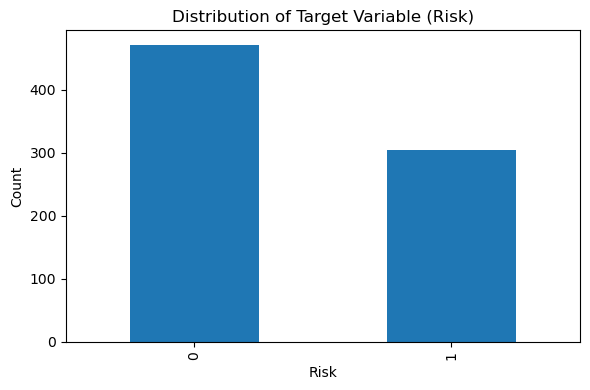

In [6]:
plt.figure(figsize=(6,4))
df["Risk"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Target Variable (Risk)")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Interpretation

The dataset contains **776 observations** and a binary target variable `Risk`.  
Only **one missing value** appears in `Money_Value`, which means the data quality is generally good.

The class distribution is not perfectly balanced, but it is not extremely skewed either.  
This means classification is feasible without heavy resampling, although class-aware evaluation is still necessary.

## 5. Understanding Possible Target Leakage

One of the most important parts of this notebook is deciding **which variables should not be used as predictors**.

The dataset contains several fields whose names strongly suggest that they are already **risk judgements, intermediate risk scores, or audit summary metrics**, for example:

- `Audit_Risk`
- `Inherent_Risk`
- `Risk_A`, `Risk_B`, `Risk_C`, `Risk_D`, `RiSk_E`, `Risk_F`
- `Score`, `Score_A`, `Score_B`, `Score_B.1`, `Score_MV`
- `CONTROL_RISK`, `Detection_Risk`, `Prob`

These variables may be highly informative, but they are also methodologically dangerous.  
If they are used directly, the model may simply learn the **construction logic of the target label**, producing unrealistically strong results.

For that reason, this notebook creates two concepts:

1. **Leakage-prone columns** → excluded from the final predictive model  
2. **Operational / raw-style columns** → retained for modelling

This decision improves the credibility of the modelling process, even if it may reduce raw predictive performance.

In [7]:
corr_with_target = df.select_dtypes(include="number").corr(numeric_only=True)["Risk"].sort_values(ascending=False)
corr_with_target.to_frame("correlation_with_Risk").head(20)

,correlation_with_Risk
Risk,1.000000
Score,0.785995
Score_MV,0.688367
Score_B,0.635768
Score_A,0.619726
CONTROL_RISK,0.416474
RiSk_E,0.411803
District_Loss,0.403806
Risk_A,0.385067
PARA_A,0.378758


The correlation table above often shows very high relationships between the target and score/risk-related variables.
That pattern is exactly why leakage control matters in this dataset.

## 6. Feature Design

To make the model more believable, I did not use the columns that are already very close to the final audit judgement.
Instead, I kept the more basic variables and added a few simple features that are easy to explain.

### 6.1 Main Variables Used

The main variables kept in the model are:

- `Sector_score`
- `LOCATION_ID`
- `PARA_A`
- `PARA_B`
- `TOTAL`
- `numbers`
- `Money_Value`
- `District_Loss`
- `PROB`
- `History`

### 6.2 Simple Engineered Features

I also created a few light features:

- `Money_Value_missing` → shows whether the money value was missing
- `log_Money_Value` → reduces skew in the money value column
- `PARA_sum` → adds `PARA_A` and `PARA_B`
- `PARA_gap` → shows the gap between `PARA_A` and `PARA_B`
- `PARA_product` → keeps a simple interaction between `PARA_A` and `PARA_B`
- `Risk_exposure_proxy` → combines `TOTAL` and `PROB`
- `Loss_history_interaction` → combines district loss and history

These features are simple on purpose. I wanted the notebook to stay readable and suitable for this module level.


In [8]:
data = df.copy()

# Basic type handling
data["LOCATION_ID"] = data["LOCATION_ID"].astype(str)

# Light feature engineering
data["Money_Value_missing"] = data["Money_Value"].isna().astype(int)
data["log_Money_Value"] = np.log1p(data["Money_Value"].fillna(data["Money_Value"].median()).clip(lower=0))
data["PARA_sum"] = data["PARA_A"] + data["PARA_B"]
data["PARA_gap"] = (data["PARA_A"] - data["PARA_B"]).abs()
data["PARA_product"] = data["PARA_A"] * data["PARA_B"]
data["Risk_exposure_proxy"] = data["TOTAL"] * (1 + data["PROB"])
data["Loss_history_interaction"] = data["District_Loss"] * (1 + data["History"])

target = "Risk"

leakage_prone_columns = [
    "Risk",
    "Audit_Risk", "Inherent_Risk",
    "Risk_A", "Risk_B", "Risk_C", "Risk_D", "RiSk_E", "Risk_F",
    "Score", "Score_A", "Score_B", "Score_B.1", "Score_MV",
    "CONTROL_RISK", "Detection_Risk", "Prob"
]

feature_cols = [c for c in data.columns if c not in leakage_prone_columns]

X = data[feature_cols].copy()
y = data[target].copy()

print("Features used:")
print(feature_cols)

Features used:
['Sector_score', 'LOCATION_ID', 'PARA_A', 'PARA_B', 'TOTAL', 'numbers', 'Money_Value', 'District_Loss', 'PROB', 'History', 'Money_Value_missing', 'log_Money_Value', 'PARA_sum', 'PARA_gap', 'PARA_product', 'Risk_exposure_proxy', 'Loss_history_interaction']


## 7. Train/Test Split and Preprocessing

A pipeline is used so that preprocessing is learned on the training set only.
This makes the workflow cleaner and helps reduce leakage.

- numeric variables → median imputation + scaling
- categorical variable (`LOCATION_ID`) → most-frequent imputation + one-hot encoding


In [9]:
categorical_features = ["LOCATION_ID"]
numeric_features = [c for c in X.columns if c not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (543, 17) (543,)
Test set: (233, 17) (233,)


## 8. Model Comparison

I compared three common models:

1. **Logistic Regression** – a clear baseline
2. **Random Forest** – useful for non-linear patterns
3. **Gradient Boosting** – another strong model for tabular data

Cross-validation is used first so that the comparison is not based on only one random split.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV Recall", ascending=False)
cv_results.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
2,Gradient Boosting,0.9897,0.9934,0.9803,0.9868,0.9990
1,Random Forest,0.9871,0.9901,0.9770,0.9835,0.9989
0,Logistic Regression,0.9729,0.9735,0.9574,0.9653,0.9954


### Brief comment on the cross-validation results

The most important metric here is **recall**, because in an audit setting it is usually worse to miss a risky case than to raise some false alarms.
I also looked at F1-score and ROC-AUC so that the judgement is not based on one metric only.

If the results still look strong after removing leakage-prone variables, that suggests the remaining variables still contain useful risk information.

## 9. Test Set Evaluation

After comparing the models in cross-validation, I evaluate the selected model on the hold-out test set.
This gives a cleaner picture of how the model performs on unseen data.


In [11]:
test_summaries = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)

    test_summaries.append({
        "Model": name,
        "Test Accuracy": (y_pred == y_test).mean(),
        "Test Precision": pd.Series(y_pred).pipe(lambda s: ((s==1) & (y_test.reset_index(drop=True)==1)).sum() / max((s==1).sum(),1)),
        "Test Recall": pd.Series(y_pred).pipe(lambda s: ((s==1) & (y_test.reset_index(drop=True)==1)).sum() / (y_test==1).sum()),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test PR-AUC": average_precision_score(y_test, y_prob)
    })

test_results = pd.DataFrame(test_summaries).sort_values("Test Recall", ascending=False)
test_results.round(4)

,Model,Test Accuracy,Test Precision,Test Recall,Test ROC-AUC,Test PR-AUC
0,Logistic Regression,0.9785,0.9677,0.9783,0.9969,0.9958
1,Random Forest,0.9914,1.0000,0.9783,1.0000,1.0000
2,Gradient Boosting,0.9871,1.0000,0.9674,0.9992,0.9989


In [12]:
best_model_name = test_results.sort_values(
    ["Test Recall", "Test ROC-AUC", "Test Accuracy"],
    ascending=False
).iloc[0]["Model"]

best_pipe = fitted_models[best_model_name]

print("Selected final model:", best_model_name)

Selected final model: Random Forest


In [13]:
y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1] if hasattr(best_pipe.named_steps["model"], "predict_proba") else best_pipe.decision_function(X_test)

print(classification_report(y_test, y_pred_best, digits=4))

              precision    recall  f1-score   support

           0     0.9860    1.0000    0.9930       141
           1     1.0000    0.9783    0.9890        92

    accuracy                         0.9914       233
   macro avg     0.9930    0.9891    0.9910       233
weighted avg     0.9915    0.9914    0.9914       233



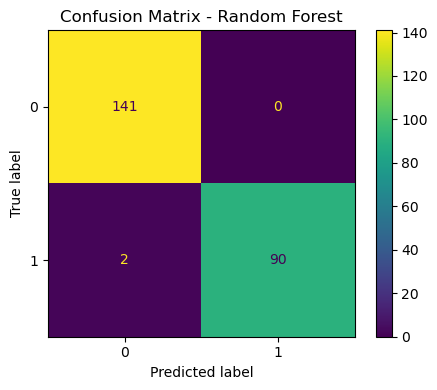

In [14]:
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

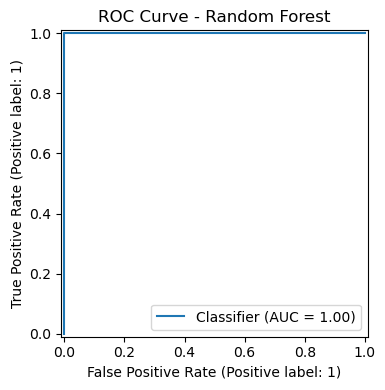

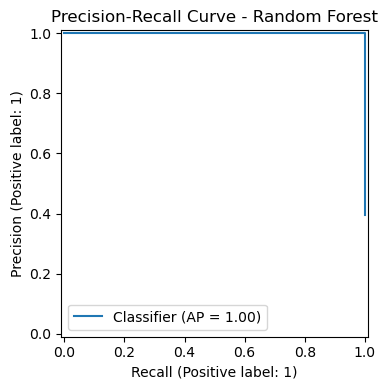

In [15]:
fig, ax = plt.subplots(figsize=(5,4))
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=ax)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,4))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_best, ax=ax)
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.tight_layout()
plt.show()

### Why this matters

From an audit point of view, recall matters because it shows whether the model can catch risky cases.
A model like this would not replace professional judgement, but it could help with early screening and case prioritisation.


## 10. Hyperparameter Tuning

To improve the Random Forest model, I use a small grid search.
I only tune one model here so that the notebook stays focused and easy to follow.

In [16]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

# A small grid is enough here for coursework and keeps the notebook quick to run.
tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 8],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=tuning_cv,
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("Best CV recall:", round(grid.best_score_, 4))


Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV recall: 0.9765


In [17]:
best_tuned_rf = grid.best_estimator_
y_pred_tuned = best_tuned_rf.predict(X_test)
y_prob_tuned = best_tuned_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, digits=4))
print("Tuned RF ROC-AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))
print("Tuned RF PR-AUC:", round(average_precision_score(y_test, y_prob_tuned), 4))

              precision    recall  f1-score   support

           0     0.9860    1.0000    0.9930       141
           1     1.0000    0.9783    0.9890        92

    accuracy                         0.9914       233
   macro avg     0.9930    0.9891    0.9910       233
weighted avg     0.9915    0.9914    0.9914       233

Tuned RF ROC-AUC: 1.0
Tuned RF PR-AUC: 1.0


## 11. Model Interpretation

It is useful to see which variables matter most in the final model.
Here I use permutation importance on the test set.
This is easier to explain than just showing the built-in importance from a tree model.


In [18]:
from sklearn.inspection import permutation_importance

final_model_for_interpretation = best_tuned_rf

perm = permutation_importance(
    final_model_for_interpretation,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="recall"
)

# Permutation importance on the full pipeline returns one value per original input column.
feature_names = X_test.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean
6,Money_Value,0.086957
11,log_Money_Value,0.075543
16,Loss_history_interaction,0.072826
7,District_Loss,0.057065
3,PARA_B,0.010870
14,PARA_product,0.007065
2,PARA_A,0.005435
1,LOCATION_ID,0.004348
4,TOTAL,0.003261
15,Risk_exposure_proxy,0.003261


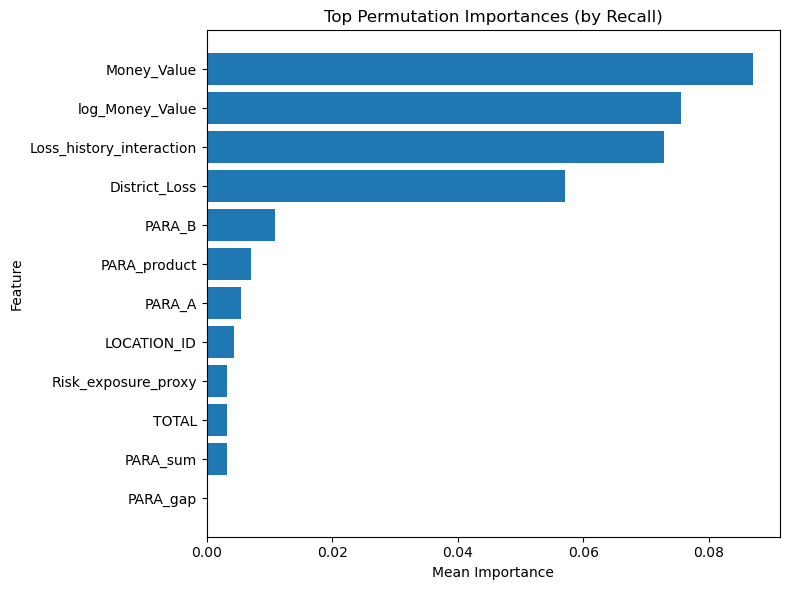

In [19]:
top_n = 12
plot_df = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(8,6))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Top Permutation Importances (by Recall)")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Short interpretation

The important features should be understood as **risk signals**, not proof of fraud.
For example, money-related variables may capture unusual exposure, while history and loss-related variables may reflect repeated weakness patterns.

So the model is best used as a support tool for audit attention, not as a final decision-maker.


## 12. Limitations

This notebook still has some limitations:

1. **Possible residual leakage**  
   Even after removing the most obvious columns, some variables may still contain indirect audit judgement.

2. **Only one dataset**  
   The findings are based on one dataset, so they may not generalise well.

3. **No time-based validation**  
   I used stratified random splits because the dataset does not clearly provide a time sequence.

4. **No threshold tuning**  
   In real work, the cut-off should be chosen based on investigation cost and false negative risk.

5. **Predictions are not evidence**  
   A high-risk prediction should lead to more review, not an automatic conclusion.


## 13. Conclusion

This notebook shows that audit risk can be analysed with a clear Python workflow and a few simple engineered features.
I tried to keep the work realistic for this module by:

- avoiding the most obvious leakage-prone variables,
- using pipelines for preprocessing,
- comparing several models,
- checking performance with cross-validation,
- and adding a short interpretation section.

Overall, the model is most useful as an **early warning tool**.
It can help auditors focus on cases that look more risky, but it should still be used together with professional judgement.


## 14. Possible Next Steps

If I wanted to extend this project later, I could add:

- threshold tuning based on business cost,
- calibration analysis,
- SHAP explanations,
- class-weight sensitivity checks,
- or a comparison between leakage-prone and leakage-controlled models.
